<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# CLase 19/03/2026
#### Jeremias Martin Pantozzi


## Primera parte Cuantizacion de un señal seno con SNR=15, con calculo de su error 

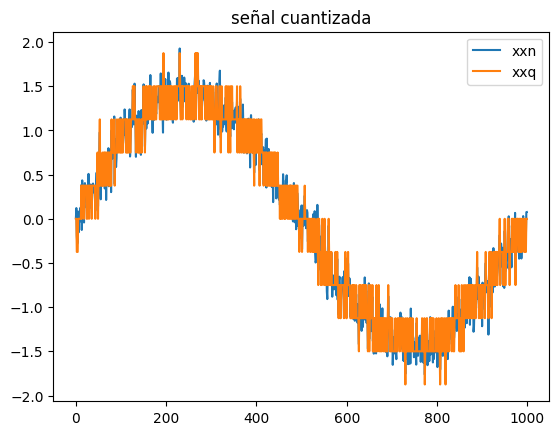

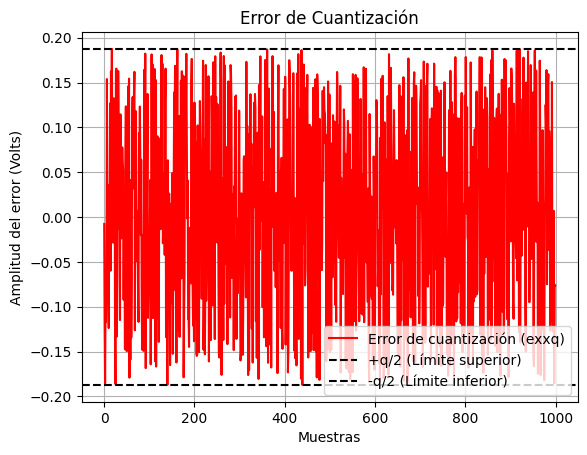

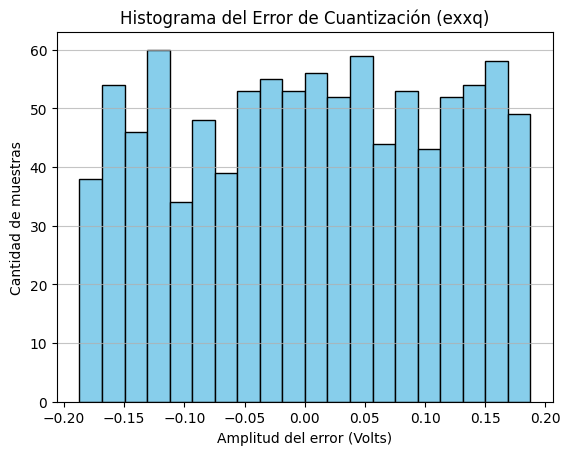

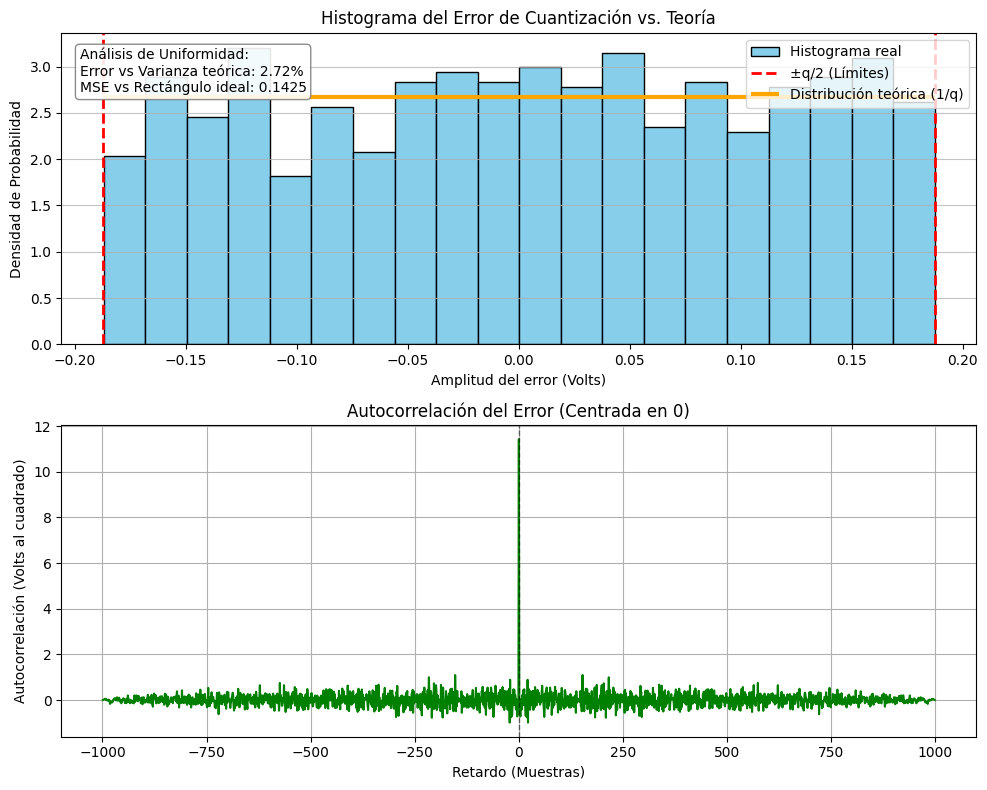

Varianza de error de cuantizacion:  0.011400417496345036
varianza teorica de error de cuantizacion:  0.01171875


In [1]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funcion seno
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx

#%% ejecucion
vmax=1
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% funcion ruido segun dB pedido

vmax=np.sqrt(2)

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

Px=np.var(xx)
SNR=15
Pr=10**(-SNR/10)
R= np.random.normal(0, np.sqrt(Pr), 1000)

xxn=xx + R

#%% cuantizacion

B = 3 #bits

Vfs = 3 #Volts

qq= Vfs / (2**B)

xxq= np.round(xxn/qq)*qq

exxq= xxq-xxn

# yyn= (1/nn) * sig.convolve(exxq, np.flip(exxq))  con este 1/nn tengo la varianza un promedio con mis muestras
yyn= sig.convolve(exxq, np.flip(exxq)) #asi tengo mi autocorrelado obteniendo mi energia
vare=np.var(exxq)

varteoe=qq**2/12

plt.figure(4)
plt.clf()
plt.plot(xxn, label = 'xxn')
plt.plot(xxq, label = 'xxq')
plt.legend()
plt.title ('señal cuantizada')
plt.show()

plt.figure(5)
plt.clf()
# Graficamos el error de cuantización
plt.plot(exxq, label='Error de cuantización (exxq)', color='red')

# Agregamos los límites teóricos (+q/2 y -q/2) para referencia
plt.axhline(qq/2, color='black', linestyle='--', label='+q/2 (Límite superior)')
plt.axhline(-qq/2, color='black', linestyle='--', label='-q/2 (Límite inferior)')

plt.legend()
plt.title('Error de Cuantización')
plt.xlabel('Muestras')
plt.ylabel('Amplitud del error (Volts)')
plt.grid(True)
plt.show()


plt.figure(6)
plt.clf()

# Graficamos únicamente el histograma de tu error calculado (exxq)
plt.hist(exxq, bins=20, color='skyblue', edgecolor='black')

plt.title('Histograma del Error de Cuantización (exxq)')
plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Cantidad de muestras')
plt.grid(axis='y', alpha=0.75)
plt.show()

#histograma 
# 2. Creamos la línea teórica de la distribución uniforme
# Va desde -q/2 hasta +q/2, y su altura es 1/q


plt.figure(7, figsize=(10, 8))
plt.clf()

# --- Primer panel: Histograma con límites y distribución teórica ---
ax1 = plt.subplot(2, 1, 1)

# Generamos el histograma normalizado (density=True)
counts, bins_edges, _ = plt.hist(exxq, bins=20, density=True, color='skyblue', edgecolor='black', label='Histograma real')

# 1. Agregamos los límites -q/2 y q/2 con líneas verticales
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2) # Sin label para no repetir en la leyenda

# 2. NUEVO: Agregamos la línea horizontal de la distribución teórica ideal (altura 1/q)
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linestyle='-', linewidth=3, label='Distribución teórica (1/q)')

# 3. Calculamos cuán uniforme es
error_varianza_pct = abs(vare - varteoe) / varteoe * 100
altura_teorica_ideal = 1 / qq
mse_uniformidad = np.mean((counts - altura_teorica_ideal)**2)

# 4. Creamos el cuadro de texto para los resultados
texto_analisis = (
    f"Análisis de Uniformidad:\n"
    f"Error vs Varianza teórica: {error_varianza_pct:.2f}%\n"
    f"MSE vs Rectángulo ideal: {mse_uniformidad:.4f}"
)

ax1.text(0.02, 0.95, texto_analisis, transform=ax1.transAxes, 
         fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title('Histograma del Error de Cuantización vs. Teoría')
plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.75)

# --- Segundo panel: Autocorrelación centrada (SIN normalizar a 1) ---
plt.subplot(2, 1, 2)

# 1. Mantenemos el vector de retardos centrado en 0
lags = np.arange(-nn + 1, nn)

# 2. Graficamos directamente tu variable original 'yyn', sin dividirla por nada
plt.plot(lags, yyn, color='green')

# Resaltamos el eje central (retardo 0)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Autocorrelación del Error (Centrada en 0)')
plt.xlabel('Retardo (Muestras)')
plt.ylabel('Autocorrelación (Volts al cuadrado)')
plt.grid(True)

plt.tight_layout()
plt.show()


print ("Varianza de error de cuantizacion: ", vare)
print ("varianza teorica de error de cuantizacion: ", varteoe)

## Segunda parte Aplicacion de FFT

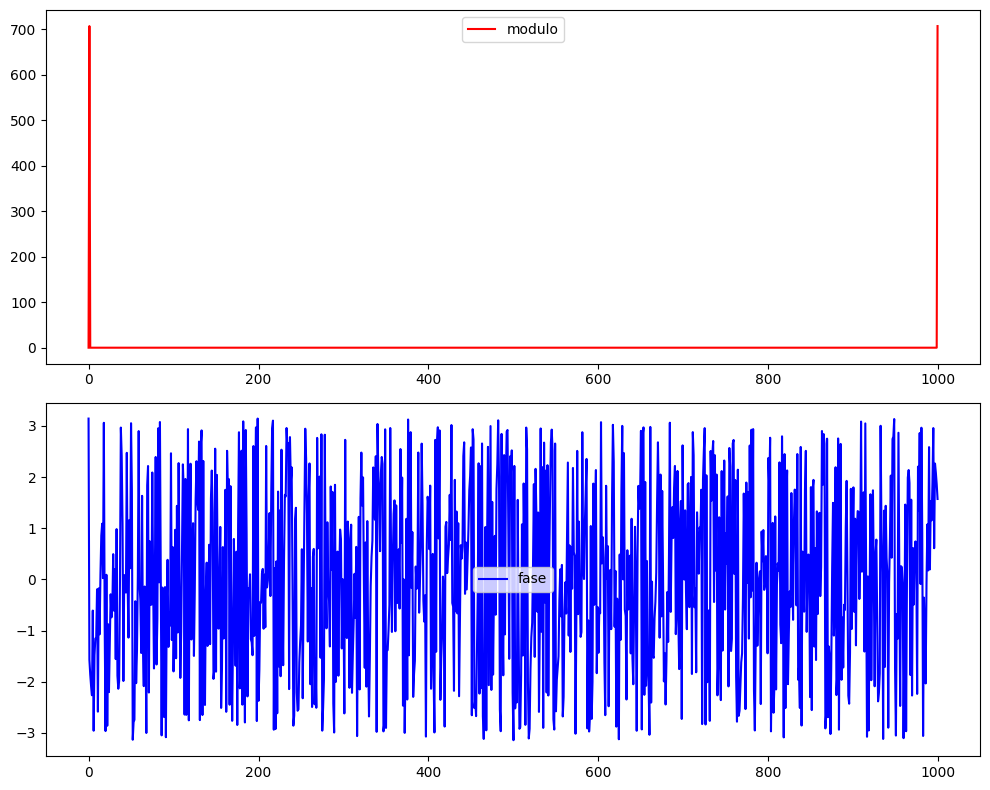

In [2]:
#%% fft
XX = np.fft.fft(xx)

XXmod= np.abs(XX)
XXphase= np.angle(XX)

plt.figure(1, figsize=(10, 8))
plt.clf()
plt.title = ('FFT de XX')
# --- Primer panel: modulo---
ax1 = plt.subplot(2, 1, 1)
plt.plot (XXmod, label = 'modulo', color = 'red')
plt.legend()

# --- Psegundo panel: fase---
ax2 = plt.subplot(2, 1, 2)
plt.plot(XXphase, label ='fase', color= 'blue')
plt.legend()
plt.tight_layout()
plt.show()
